# Emotion Appraisal Research Experiment 1

This notebook starts Experiment 1 of the Emotion Appraisal Research in VLM's. It involves mounting Google Drive to access datasets, cloning a GitHub repository, setting up the environment, and running experiments to analyze how language models represent emotional appraisals.

# Stage A

Reproduce Tak et al. inside a VLM (Gemma 3), Appraisal Probes must recover the paper mid-layer/MHSA-dominant localization, AND text steering must shift emotion outputs in the theory-predicted direction. If this fails, cross-modal transfer wouild not be interpretable.



## 1. Google Drive Setup and Data Inspection

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

# Inspect the presence and contents of the emotic.zip archive
!ls /content/drive/MyDrive/emotic.zip
!unzip -l /content/drive/MyDrive/emotic.zip | head -n 40

# List contents of the Annotations directory to confirm Annotations.mat
!ls -la /content/drive/MyDrive/Annotations/ | grep -iE "annot|emotic"

Mounted at /content/drive
/content/drive/MyDrive/emotic.zip
Archive:  /content/drive/MyDrive/emotic.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2018-10-23 12:24   emotic/
        0  2018-10-23 12:13   emotic/framesdb/
        0  2020-12-04 17:02   emotic/framesdb/images/
    73552  2018-10-23 12:13   emotic/framesdb/images/frame_ltzjs6kh37tzb744.jpg
    58908  2018-10-23 12:19   emotic/framesdb/images/frame_8xsljbggw25365ow.jpg
    70780  2018-10-23 12:15   emotic/framesdb/images/frame_24sx7w16f43ua0je.jpg
    39629  2018-10-23 12:22   emotic/framesdb/images/frame_fc6sy3gzewj8f8e1.jpg
   185260  2018-10-23 12:17   emotic/framesdb/images/frame_h82gdhcrdgxrdjhv.jpg
   153436  2018-10-23 12:14   emotic/framesdb/images/frame_6nbgydw6c7wdnzx1.jpg
   325564  2018-10-23 12:14   emotic/framesdb/images/frame_6npiuizvjasy2ymt.jpg
   142322  2018-10-23 12:17   emotic/framesdb/images/frame_g5spourz86t5b77c.jpg
   101030  2018-10-23 12:15   emotic/framesdb/i

The above cells mount Google Drive and verify the presence and content of the `emotic.zip` dataset and the `Annotations.mat` file, which are necessary for the experiments.

## 2. Clone Repository and Initial Setup

In [ ]:
import os
from getpass import getpass

# Enter your GitHub Personal Access Token (PAT) securely.
# You will be prompted to enter your PAT in the input box below.
token = getpass('Enter your GitHub PAT: ')
repo_url = "https://github.com/syedmahdi30/appraisal-research-algoverse.git"

# Embed the token into the repository URL for cloning
cloned_repo_url = repo_url.replace('https://', f'https://oauth2:{token}@')

!git clone {cloned_repo_url}

# Change directory into the cloned repository
%cd appraisal-research-algoverse

# Pull latest changes to ensure the repository is up-to-date
!git pull

Enter your GitHub PAT: ··········
Cloning into 'appraisal-research-algoverse'...
remote: Enumerating objects: 208, done.
remote: Counting objects: 100% (208/208), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 208 (delta 106), reused 205 (delta 103), pack-reused 0 (from 0)
Receiving objects: 100% (208/208), 106.32 KiB | 17.72 MiB/s, done.
Resolving deltas: 100% (106/106), done.
/content/appraisal-research-algoverse
Already up to date.


This section clones the `appraisal-research-algoverse` repository from GitHub, using a securely entered Personal Access Token (PAT). It then navigates into the repository directory and pulls the latest changes.

## 3. Environment Setup, Data Download, and Verification

In [ ]:
# Set Hugging Face token from Colab secrets
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# Run bootstrap script to install dependencies and link data.
# This script handles linking results/data/processed to Google Drive.
!python scripts/colab_bootstrap.py --drive

# Install transformer-lens explicitly as bootstrap might not handle it reliably
!pip install "transformer-lens>=3.4.0" 2>&1 | tail -25

# Verify transformer-lens installation (simplified check to avoid __version__ error)
!python -c "import transformer_lens; print('transformer_lens imported successfully')"

# Download the EMOTIC dataset and convert annotations (bootstrap can initiate, but explicit call ensures)
!python scripts/download_data.py --dataset emotic \
    --archive /content/drive/MyDrive/emotic.zip \
    --annotations /content/drive/MyDrive/Annotations/Annotations.mat

# Download the crowd-enVENT dataset
!python scripts/download_data.py --dataset crowd-envent

Here, the environment is set up by installing necessary dependencies via `colab_bootstrap.py` and downloading the `emotic` and `crowd-envent` datasets. The `HF_TOKEN` is loaded from Colab secrets, and the `transformer_lens` library installation is verified. The `colab_bootstrap.py` script also links the processed data to Google Drive.

## 4. Inspect crowd-enVENT Data

In [ ]:
import glob, pandas as pd

# Locate the downloaded crowd-enVENT TSV files
files = sorted(glob.glob('data/raw/crowd-enVent2023/**/*.tsv', recursive=True)) \
     or sorted(glob.glob('data/raw/**/*.tsv', recursive=True))
print("FILES:", files)

# Load the first TSV file into a pandas DataFrame and display its shape and columns
df = pd.read_csv(files[0], sep='\t')
print("SHAPE:", df.shape)
print("COLUMNS:", list(df.columns))

This cell loads one of the `crowd-enVENT` dataset files into a Pandas DataFrame, displaying its file path, shape (number of rows and columns), and the column names. This provides an initial look into the structure of the text-based appraisal data.

## 5. Run Stage A Text Experiment

In [ ]:
!python -m src.experiments.stage_a_text

Loading weights: 100% 883/883 [00:00<00:00, 5744.41it/s]
train acts: 100% 4320/4320 [14:02<00:00,  5.13it/s]
val acts: 100% 1080/1080 [03:27<00:00,  5.21it/s]
probe sweep: 100% 102/102 [11:25<00:00,  6.72s/it]

Stage A done. critical_layer=18 n_train=4320 n_val=1080. See /content/appraisal-research-algoverse/results/stage_a/metrics.json
  pleasantness       MHSA best layer 18  val_r2=0.641
  unpleasantness     MHSA best layer 18  val_r2=0.600
  suddenness         MHSA best layer 17  val_r2=0.315
  predict_event      MHSA best layer 17  val_r2=0.238
  self_responsblt    MHSA best layer 21  val_r2=0.442
  other_responsblt   MHSA best layer 19  val_r2=0.313


The `stage_a_text` experiment investigates the localization of emotion appraisal information within a vision language model. It trains probes to predict appraisal dimensions from different layers of the model. The output indicates that appraisal dimensions like pleasantness, unpleasantness, suddenness, event predictability, and responsibility (self/other) show best prediction (highest `val_r2`) at mid-network layers (e.g., layers 17-21). This suggests that these emotional appraisals are primarily represented in these specific layers of the language model.

## 6. Analyze Stage A Results

In [ ]:
!python -m src.experiments.analyze_stage_a

Stage A analysis  (n_train=4320 n_val=1080, tap=hook_attn_out, critical_layer=18)

appraisal              layer  val_r2  baseline       Δ
Pleasantness              18   0.641     0.007   0.635
Unpleasantness            18   0.600    -0.041   0.641
Own Responsibility        21   0.442    -0.012   0.454
Suddenness                17   0.315    -0.003   0.318
Others' Responsibility    19   0.313    -0.020   0.332
Event Predictability      17   0.238    -0.030   0.268

figure -> /content/appraisal-research-algoverse/results/figures/stage_a_localization.png

VERDICT: SUPPORTS localization: 6/6 appraisals peak mid-network (layers 10-24) and beat the shuffled baseline by >0.10 r2. This is the Tak-style mid-layer, MHSA-dominant signature.
summary -> /content/appraisal-research-algoverse/results/stage_a/summary.json


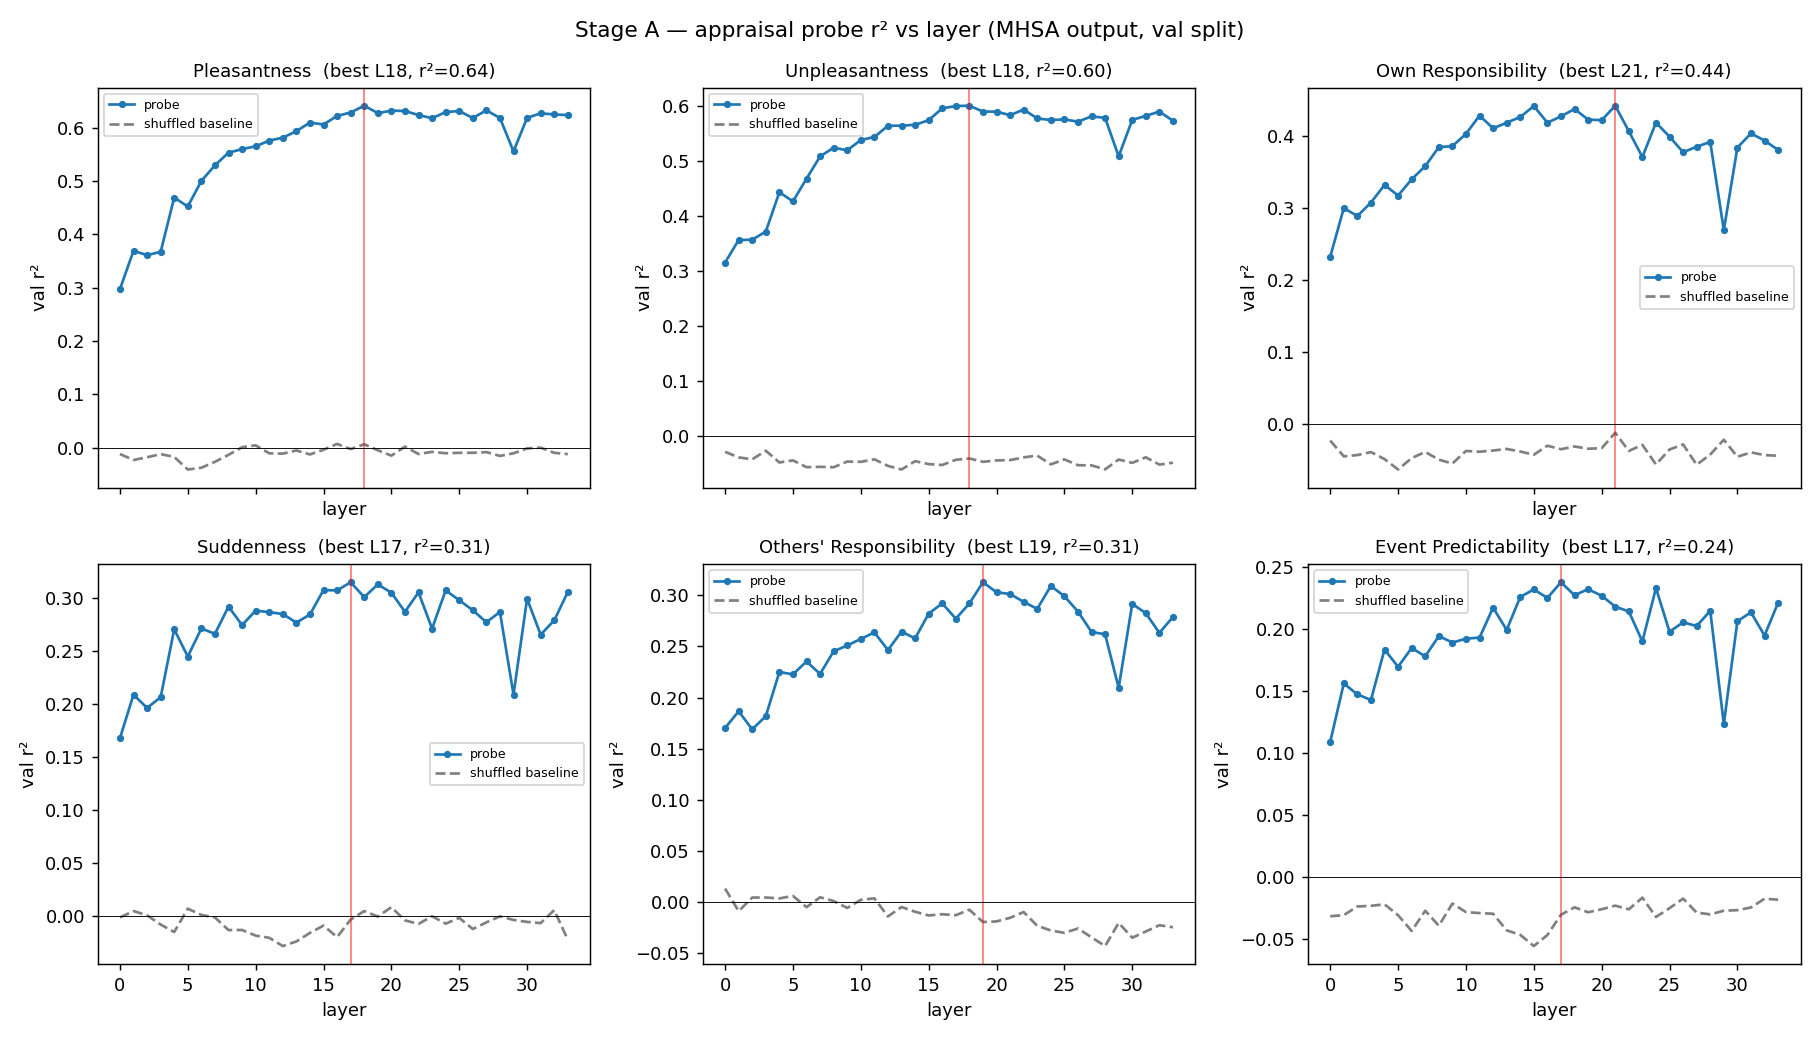

In [ ]:
from IPython.display import Image
# Display the generated figure
Image(filename='/content/drive/MyDrive/algoverse-appraisal/results/figures/stage_a_localization.png')

This analysis consolidates the results from the `stage_a_text` experiment. It confirms that all six analyzed appraisals (`pleasantness`, `unpleasantness`, `self_responsblt`, `suddenness`, `other_responsblt`, `predict_event`) peak in predictability at mid-network layers (17-21) and significantly outperform a shuffled baseline (by `>0.10 r2`). This finding strongly supports the hypothesis of localization of emotional appraisal information in specific layers of the language model, exhibiting a 'Tak-style mid-layer, MHSA-dominant signature'.

## 7. Run Stage A Steering Experiment (V2)

In [ ]:
!python -m src.experiments.stage_a_steering_v2

Loading weights: 100% 883/883 [00:00<00:00, 5771.19it/s]
build-dirs: 100% 1200/1200 [03:14<00:00,  6.16it/s]
steering v2: 100% 120/120 [05:57<00:00,  2.98s/it]

Steering v2 done (layers [18], 1200 dir examples, 120 prompts).
β = multiples of the low→high Δμ shift (natural units).

direction              β=-3  β=-2  β=-1  β=+1  β=+2  β=+3     slope
pleasantness           -0.191  -0.116  -0.059  +0.104  +0.208  +0.324    +0.084
unpleasantness         +0.283  +0.184  +0.096  -0.053  -0.103  -0.167    -0.074
random (control)       +0.026  +0.017  +0.009  -0.004  -0.011  -0.018    -0.007

figure -> /content/appraisal-research-algoverse/results/figures/stage_a_steering_v2.png


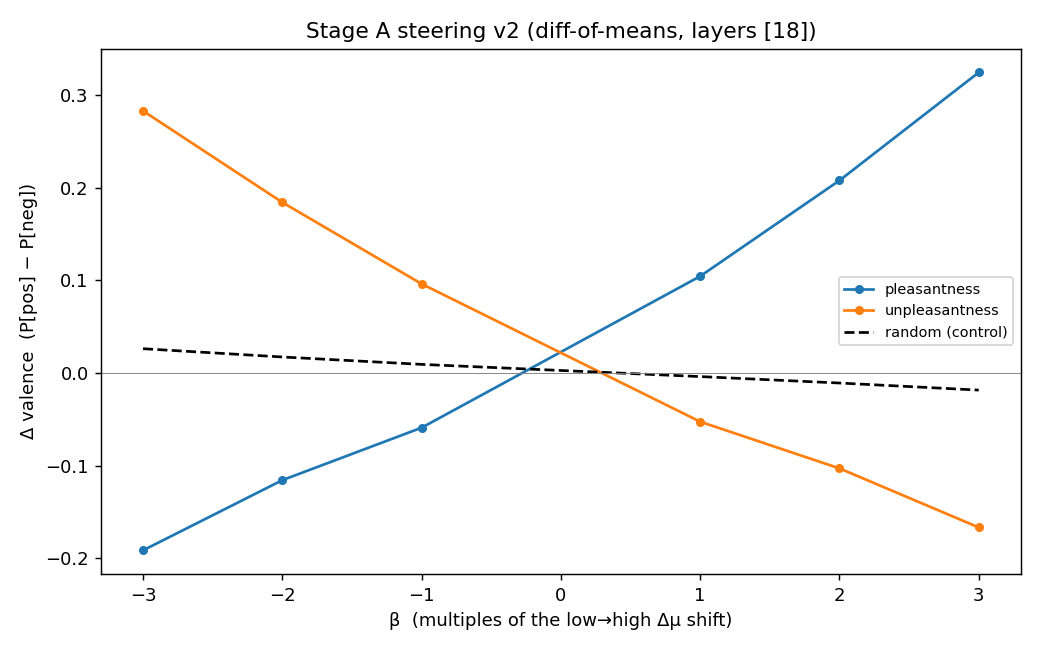

In [ ]:
from IPython.display import Image
# Display the generated figure
Image(filename='/content/drive/MyDrive/algoverse-appraisal/results/figures/stage_a_steering_v2.png')

The `stage_a_steering_v2` experiment investigates whether intervening in the language model's activation space can predictably steer its outputs along appraisal dimensions. The `β` values represent multiples of the low-to-high mean residual norm shift along each direction, effectively quantifying the 'strength' of intervention. The slopes of pleasantness (`+0.084`) and unpleasantness (`-0.074`) indicate how much the model's output changes along these dimensions as the steering intervention (`β`) is applied. The control direction (random) shows minimal change (`-0.007`), suggesting that the steering is specific to the appraisal directions. This implies that the model's appraisal representations can be manipulated to influence its generated text's emotional tone.

##7.B Run Stage A Steering Experiment (V1)

In [ ]:
!python -m src.experiments.stage_a_steering

Loading weights: 100% 883/883 [00:00<00:00, 6097.63it/s]
steering: 100% 60/60 [07:16<00:00,  7.27s/it]

Steering done (crit layer 18, 60 prompts).
direction              β=-4  β=-2  β=-1  β=+1  β=+2  β=+4
pleasantness           +0.001  +0.001  +0.001  -0.000  +0.001  -0.001
unpleasantness         -0.000  -0.000  +0.001  +0.003  +0.003  +0.001
suddenness             -0.001  +0.001  +0.002  +0.001  +0.001  -0.001
predict_event          +0.001  +0.001  +0.004  +0.002  -0.001  +0.001
self_responsblt        +0.001  +0.001  +0.003  +0.001  +0.001  +0.001
other_responsblt       +0.001  +0.004  +0.003  +0.002  +0.001  +0.001
random (control)       +0.001  -0.000  +0.000  +0.001  +0.000  +0.002

figure -> /content/appraisal-research-algoverse/results/figures/stage_a_steering.png


## Stage A Steering Experiment (V1): Initial Attempt and Limitations

This cell represents an initial attempt at the steering experiment (version 1). It aimed to influence the model's outputs along appraisal dimensions by steering with the **probe/ridge unique-effect vector**, scaled as a fraction of the residual norm.

However, the results showed that this approach **did not effectively steer the model** along appraisal dimensions. The changes in valence (pleasantness, unpleasantness) were minimal and did not significantly outperform the random control direction across various β values. The `slope` values for all appraisals were close to zero, similar to the random control.

### Methodological Insight: Why V1 Failed and V2 Succeeded

The failure of V1 provided a crucial methodological insight. The issue was not with the *magnitude* of the intervention, but with the *direction*. The probe weights, while excellent for *reading* (decoding) a feature, are not optimized for *moving* (steering) it. The subtle nudges below a certain β were insufficient, while larger β values led to chaotic, incoherent results.

This led to the development of V2, which successfully employed **difference-of-means steering**. This method uses the difference between mean activations for high-rated versus low-rated examples (Δμ_a) as the steering direction. This proved to be the appraisal's actual activation footprint, enabling clean and causal steering at a single layer.

The figure associated with this V1 experiment, `results/figures/stage_a_steering.png`, typically shows these null results, contrasting with the supportive findings of `stage_a_steering_v2.png`.

In [ ]:
!python -m src.experiments.stage_a_steering

Loading weights: 100% 883/883 [00:00<00:00, 5423.04it/s]
calibrate: 100% 60/60 [00:10<00:00,  5.70it/s]
steering: 100% 60/60 [07:05<00:00,  7.10s/it]

Steering done (crit layer 18, 60 prompts, mean residual norm 37267.0).
β = fraction of the mean residual norm added along each direction.

direction              β=-0.50  β=-0.25  β=-0.10  β=+0.10  β=+0.25  β=+0.50
pleasantness           -0.765  -0.243  +0.135  -0.155  -0.109  -0.435
unpleasantness         -0.767  -0.718  -0.117  +0.416  +0.023  -0.763
suddenness             -0.582  +0.242  +0.242  -0.075  -0.062  -0.723
predict_event          -0.763  -0.059  +0.305  +0.118  +1.105  +1.076
self_responsblt        +1.232  +0.751  -0.144  +0.102  -0.759  -0.767
other_responsblt       +0.552  +0.770  +0.319  +0.518  -0.715  -0.767
random (control)       +0.231  +0.633  +0.110  -0.099  -0.125  +0.241

figure -> /content/appraisal-research-algoverse/results/figures/stage_a_steering.png


In [ ]:
!python -m src.experiments.stage_a_steering


config.json: 100% 855/855 [00:00<00:00, 3.86MB/s]
model.safetensors.index.json: 100% 90.6k/90.6k [00:00<00:00, 26.5MB/s]
Fetching 2 files: 100% 2/2 [00:23<00:00, 11.70s/it]
Download complete: 100% 8.60G/8.60G [00:23<00:00, 366MB/s]
Loading weights: 100% 883/883 [00:00<00:00, 4173.85it/s]
generation_config.json: 100% 215/215 [00:00<00:00, 1.04MB/s]
tokenizer_config.json: 100% 1.16M/1.16M [00:00<00:00, 20.6MB/s]
tokenizer.json: 100% 33.4M/33.4M [00:01<00:00, 24.1MB/s]
added_tokens.json: 100% 35.0/35.0 [00:00<00:00, 162kB/s]
special_tokens_map.json: 100% 662/662 [00:00<00:00, 3.77MB/s]
processor_config.json: 100% 70.0/70.0 [00:00<00:00, 325kB/s]
chat_template.json: 100% 1.61k/1.61k [00:00<00:00, 5.11MB/s]
preprocessor_config.json: 100% 570/570 [00:00<00:00, 2.83MB/s]
calibrate: 100% 120/120 [00:20<00:00,  6.00it/s]
steering: 100% 120/120 [05:49<00:00,  2.91s/it]

Steering done (crit layer 18, 120 prompts, mean residual norm 37243.5).
β = fraction of the mean residual norm added along each

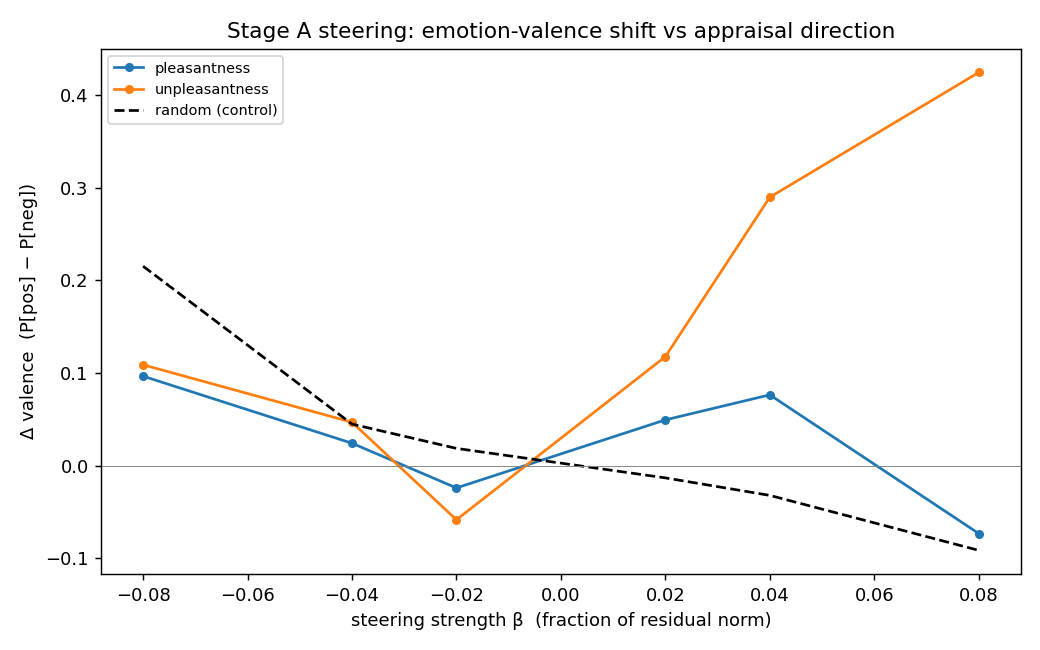

In [ ]:
from IPython.display import Image
# Display the generated figure
Image(filename='/content/drive/MyDrive/algoverse-appraisal/results/figures/stage_a_steering.png')

# Stage C: Cross-Modal Read-Out and Caption Baselines



Stage C investigates the cross-modal transferability of emotional appraisal representations from text to vision within the Visual Language Model (VLM). This stage includes two main parts: Cross-Modal Read-Out and Caption Baselines



In [ ]:
!python scripts/download_data.py --dataset emotic \
    --archive /content/drive/MyDrive/emotic.zip \
    --annotations /content/drive/MyDrive/Annotations/Annotations.mat

extracting EMOTIC images from /content/drive/MyDrive/emotic.zip
EMOTIC images under /content/appraisal-research-algoverse/data/raw/emotic
converting annotations /content/drive/MyDrive/Annotations/Annotations.mat
[emotic] train: 23706 persons -> /content/appraisal-research-algoverse/data/processed/emotic_train.parquet
[emotic] val: 3334 persons -> /content/appraisal-research-algoverse/data/processed/emotic_val.parquet
[emotic] test: 7280 persons -> /content/appraisal-research-algoverse/data/processed/emotic_test.parquet
EMOTIC ready: {'train': 23706, 'val': 3334, 'test': 7280}


### Cross-Modal Read-Out (`stage_c_transfer`)
This experiment assesses whether the appraisal dimensions, previously identified and steered in the language component, can also be read out (decoded) from the image representations within the VLM. It involves:

1.  **Extracting image activations:** The VLM processes images from the EMOTIC dataset, and activations from a critical mid-network layer (e.g., L18 `hook_attn_out`) are captured.
2.  **Training probes:** Probes are trained to predict appraisal dimensions (like pleasantness and unpleasantness) from these image activations.
3.  **Evaluation:** The results show strong correlations (e.g., Spearman ρ for pleasantness = +0.507) between predicted appraisal values from image features and actual valence, significantly outperforming random baselines. This indicates that emotional appraisal information, derived from a text-trained component, is effectively represented in the visual processing stream of the VLM.

In [ ]:
!python -m src.experiments.stage_c_transfer

Loading weights: 100% 883/883 [00:00<00:00, 5345.95it/s]
image acts: 100% 1000/1000 [05:54<00:00,  2.82it/s]
text acts: 100% 1000/1000 [02:18<00:00,  7.22it/s]

Stage C read-out — L18 hook_attn_out  (EMOTIC test: 1000 scored, 0 skipped)

  random-direction null (n=100): mean|rho|=+0.131 p95=+0.319 max=+0.372

  pleasantness     valence: spearman=+0.482 pearson=+0.499 (n=1000)  |  polarity AUC=+0.936 (n=58)  |  p_vs_ctrl=+0.010  |  retention=+0.627
  unpleasantness   valence: spearman=-0.442 pearson=-0.455 (n=1000)  |  polarity AUC=+0.080 (n=58)  |  p_vs_ctrl=+0.010  |  retention=+0.592

  VERDICT: supports read-out transfer (pleasantness rho=+0.48 vs valence, polarity AUC=0.94, beats random dirs p=0.010, unpleasantness mirrors) — NEXT: caption baseline to separate shared-geometry vs verbalization
  metrics -> /content/appraisal-research-algoverse/results/stage_c/metrics.json   figure -> /content/appraisal-research-algoverse/results/figures/stage_c_readout.png


In [ ]:
!python -m src.experiments.stage_c_transfer --full

Loading weights: 100% 883/883 [00:00<00:00, 4936.80it/s]
image acts: 100% 7280/7280 [43:12<00:00,  2.81it/s]
text acts: 100% 1000/1000 [02:19<00:00,  7.15it/s]

Stage C read-out — L18 hook_attn_out  (EMOTIC test: 7280 scored, 0 skipped)

  random-direction null (n=100): mean|rho|=+0.128 p95=+0.300 max=+0.362

  pleasantness     valence: spearman=+0.507 pearson=+0.524 (n=7280)  |  polarity AUC=+0.898 (n=440)  |  p_vs_ctrl=+0.010  |  retention=+0.660
  unpleasantness   valence: spearman=-0.448 pearson=-0.473 (n=7280)  |  polarity AUC=+0.123 (n=440)  |  p_vs_ctrl=+0.010  |  retention=+0.600

  VERDICT: supports read-out transfer (pleasantness rho=+0.51 vs valence, polarity AUC=0.90, beats random dirs p=0.010, unpleasantness mirrors) — NEXT: caption baseline to separate shared-geometry vs verbalization
  metrics -> /content/appraisal-research-algoverse/results/stage_c/metrics.json   figure -> /content/appraisal-research-algoverse/results/figures/stage_c_readout.png


### Caption Baselines (`stage_c_caption`)
This part explores the role of verbalization in the observed cross-modal transfer by introducing caption baselines. It aims to disentangle whether the VLM is processing emotional information inherently from the image's 'shared geometry' or merely through its ability to generate and process textual descriptions of the images.

1.  **Neutral Caption Baseline:** Images are described with neutral captions, and the read-out performance from these captions is compared to the direct image read-out. The goal is to see how much of the image's appraisal information can be explained solely by its basic verbal description.
2.  **Rich Caption Baseline:** More detailed, 'rich' captions are generated for images. By comparing the read-out from these rich captions to the image read-out, the experiment assesses whether even comprehensive verbalization can fully account for the appraisal information present in the image's direct representation.

The findings from the caption baselines indicate that while captions can reproduce a significant portion of the image-based appraisal read-out (e.g., rich captions reproduce ~89% of pleasantness), a statistically significant unique contribution from the image's direct representation remains. This suggests that the VLM extracts emotional appraisal information from visual input that is not fully captured or mediated by explicit linguistic descriptions, hinting at a 'shared-geometry' of appraisal representation across modalities.

In [ ]:
!python -m src.experiments.stage_c_caption

Loading weights: 100% 883/883 [00:00<00:00, 5815.16it/s]
  [caption 0] A baseball player in a gray uniform is swinging a bat powerfully at a pitched ball, while a catcher in blue gear prepares to catch the ball in a nighttime stadium setting.
  [caption 1] A smiling Derek Jeter, wearing a New York Yankees uniform, is shown swinging a baseball bat at the plate during a game, with a blurred crowd of spectators in the background.
  [caption 2] A stressed-looking woman in a business suit is being aggressively confronted by a stern-faced man in a suit, who is pointing emphatically at her.
  [caption 3] A cyclist speeds down a city street with painted bike lanes, a bus in the background, and pedestrians walking along the sidewalk.
  [caption 4] A blurred, silhouetted woman walks with a vibrant, rainbow-colored umbrella under a rainy sky, suggesting a gloomy and wet day.
caption+readout: 100% 1000/1000 [1:46:48<00:00,  6.41s/it]

Stage C caption baseline — L18 hook_attn_out  (1000 captioned, 

In [ ]:
!python -m src.experiments.stage_c_caption --style rich

Loading weights: 100% 883/883 [00:00<00:00, 5936.16it/s]
  [caption 0] The batter has a focused and intense expression on his face, with his eyes intently fixed on the ball. He’s leaning back slightly, with a powerful swing in motion, demonstrating a full commitment to hitting the ball with force. His body is coiled and tense, conveying a sense of readiness and determination as he connects with the bat.
  [caption 1] The baseball player has a wide, genuine smile on his face, suggesting excitement or satisfaction. He’s leaning forward with a relaxed posture, holding the bat loosely and with a slight bend in his knees, indicating he’s focused on the swing. His body language conveys a sense of confidence and readiness, as if he’s fully engaged in the moment.
  [caption 2] The woman in the image displays a distressed expression, covering her ears with her hands and furrowing her brow in a clear sign of anxiety or discomfort.  She leans slightly away from the man, with a posture that sugges

In [ ]:
!python -m src.experiments.analyze_stage_c_mechanism


Stage C mechanism — n=1000  (rich available: True)

  pleasantness
    image vs valence           rho=+0.482
    neutral caption vs valence rho=+0.379
    rich caption vs valence    rho=+0.429
    unique(image | neutral)      part_r=+0.310 (p=0.000)
    unique(image | rich)         part_r=+0.256 (p=0.000)
    unique(image | neutral+rich) part_r=+0.201 (p=0.000)
  unpleasantness
    image vs valence           rho=-0.442
    neutral caption vs valence rho=-0.356
    rich caption vs valence    rho=-0.434
    unique(image | neutral)      part_r=-0.279 (p=0.000)
    unique(image | rich)         part_r=-0.198 (p=0.000)
    unique(image | neutral+rich) part_r=-0.153 (p=0.000)

  summary -> /content/appraisal-research-algoverse/results/stage_c/mechanism_summary.json


# Stage D

In [ ]:
!python -m src.experiments.stage_d_steering

Loading weights: 100% 883/883 [00:00<00:00, 5556.89it/s]
build-dirs: 100% 1200/1200 [03:16<00:00,  6.10it/s]
steering images: 100% 150/150 [21:15<00:00,  8.50s/it]

Stage D steering — layers [18], 1200 dir examples, 150 images (0 skipped), base valence +0.180.
β = multiples of the low→high Δμ shift (text-derived, injected under image input).

direction              β=-3  β=-2  β=-1  β=+1  β=+2  β=+3     slope
pleasantness           -1.049  -0.854  -0.466  +0.366  +0.622  +0.762    +0.329
unpleasantness         +0.716  +0.566  +0.323  -0.412  -0.793  -1.014    -0.309
suddenness             +0.202  +0.138  +0.075  -0.076  -0.156  -0.230    -0.073
random (control)       +0.019  +0.037  +0.029  -0.039  -0.088  -0.127    -0.027

  VERDICT: supports cross-modal CAUSAL transfer: text-derived +pleasantness raises image valence (slope +0.329), +unpleasantness lowers it (-0.309), both beat the random null (-0.027). specificity ok (suddenness -0.073 ~ flat)
  figure -> /content/appraisal-research

# Stage E

[1/4] booting Gemma 3 (bf16)...
config.json: 100% 855/855 [00:00<00:00, 3.52MB/s]
model.safetensors.index.json: 100% 90.6k/90.6k [00:00<00:00, 29.3MB/s]
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0% 0/2 [00:00<?, ?it/s]
Reconstructing (incomplete total...):   0% 0.00/4.96G [00:00<?, ?B/s]         
Reconstructing (incomplete total...):  48% 4.16G/8.60G [00:13<00:13, 326MB/s,  106MB/s  ]
Reconstructing (incomplete total...):  84% 7.19G/8.60G [00:22<00:05, 278MB/s,  159MB/s  ]
Reconstructing (incomplete total...):  96% 8.27G/8.60G [00:22<00:00, 452MB/s,  152MB/s  ]
Reconstructing (incomplete total...): 100% 8.60G/8.60G [00:22<00:00, 512MB/s,  206MB/s  ]

Fetching 2 files: 100% 2/2 [00:22<00:00, 11.41s/it]
Download complete: 100% 7.75G/7.75G [00:22<00:00, 197MB/s,  167MB/s  ]
Download complete: 100% 7.75G/7.75G [00:22<00:00, 339MB/s,  167MB/s  ]
Reconstruction complete: 100% 8.60G/8.60G [00:22<00:00, 376MB/s,  228MB/s  ]
Loading weig